In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


orders = pd.read_csv('olist_orders_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
items = pd.read_csv('olist_order_items_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
category = pd.read_csv('product_category_name_translation.csv')


print("Orders:", orders.shape)
print("Customers:", customers.shape)
print("Items:", items.shape)
print("Products:", products.shape)
print("Payments:", payments.shape)
print("Reviews:", reviews.shape)

ModuleNotFoundError: No module named 'pandas'

In [ ]:



df = orders.merge(customers, on='customer_id', how='left')


df = df.merge(items, on='order_id', how='left')


df = df.merge(payments, on='order_id', how='left')


df = df.merge(products, on='product_id', how='left')


df = df.merge(category, on='product_category_name', how='left')

df = df.merge(reviews, on='order_id', how='left')

print("Final Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing Values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Final Dataset Shape: (119143, 37)

Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english', 'review_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

Missing Values:
order_approved_at                   177
order_delivered_carrier_date       2086
order_delivered_customer_date      3421
order_item_id             

In [ ]:



date_cols = ['order_purchase_timestamp', 'order_approved_at','order_delivered_customer_date', 'order_estimated_delivery_date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col])


df['review_comment_message'] = df['review_comment_message'].fillna('No Comment')
df['review_comment_title'] = df['review_comment_title'].fillna('No Title')


df['product_category_name_english'] = df['product_category_name_english'].fillna('Unknown')


df_clean = df.dropna(subset=['price', 'payment_value'])


df_clean = df_clean.copy()
df_clean['year'] = df_clean['order_purchase_timestamp'].dt.year
df_clean['month'] = df_clean['order_purchase_timestamp'].dt.month
df_clean['total_order_value'] = df_clean['price'] + df_clean['freight_value']

print("Clean Dataset Shape:", df_clean.shape)
print("Removed rows:", len(df) - len(df_clean))
print("\nOrder Status Distribution:")
print(df_clean['order_status'].value_counts())

Clean Dataset Shape: (118307, 40)
Removed rows: 836

Order Status Distribution:
order_status
delivered      115720
shipped          1255
canceled          570
invoiced          376
processing        376
unavailable         7
approved            3
Name: count, dtype: int64


In [ ]:


import datetime as dt


snapshot_date = df_clean['order_purchase_timestamp'].max() + dt.timedelta(days=1)


rfm = df_clean.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'nunique',
    'total_order_value': 'sum'
}).reset_index()

rfm.columns = ['customer_id', 'Recency', 'Frequency', 'Monetary']


rfm['R_Score'] = pd.qcut(rfm['Recency'], q=4, labels=[4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1,2,3,4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=4, labels=[1,2,3,4])


rfm['RFM_Score'] = rfm['R_Score'].astype(int) + rfm['F_Score'].astype(int) + rfm['M_Score'].astype(int)

# Segment customers
def segment(score):
    if score >= 10:
        return 'Champions'
    elif score >= 7:
        return 'Loyal Customers'
    elif score >= 5:
        return 'At Risk'
    else:
        return 'Lost Customers'

rfm['Segment'] = rfm['RFM_Score'].apply(segment)

print("RFM Table Sample:")
print(rfm.head())
print("\nCustomer Segments:")
print(rfm['Segment'].value_counts())

RFM Table Sample:
                        customer_id  Recency  Frequency  Monetary R_Score  \
0  0000366f3b9a7992bf8c76cfdf3221e2      116          1    141.90       4   
1  0000b849f77a49e4a4ce2b2a4ca5be3f      119          1     27.19       4   
2  0000f46a3911fa3c0805444483337064      542          1     86.22       1   
3  0000f6ccb0745a6a4b88665a16c9f078      326          1     43.62       2   
4  0004aac84e0df4da2b147fca70cf8255      293          1    196.89       2   

  F_Score M_Score  RFM_Score          Segment  
0       1       3          8  Loyal Customers  
1       1       1          6          At Risk  
2       1       2          4   Lost Customers  
3       1       1          4   Lost Customers  
4       1       4          7  Loyal Customers  

Customer Segments:
Segment
Loyal Customers    49764
At Risk            23944
Champions          15493
Lost Customers      6218
Name: count, dtype: int64


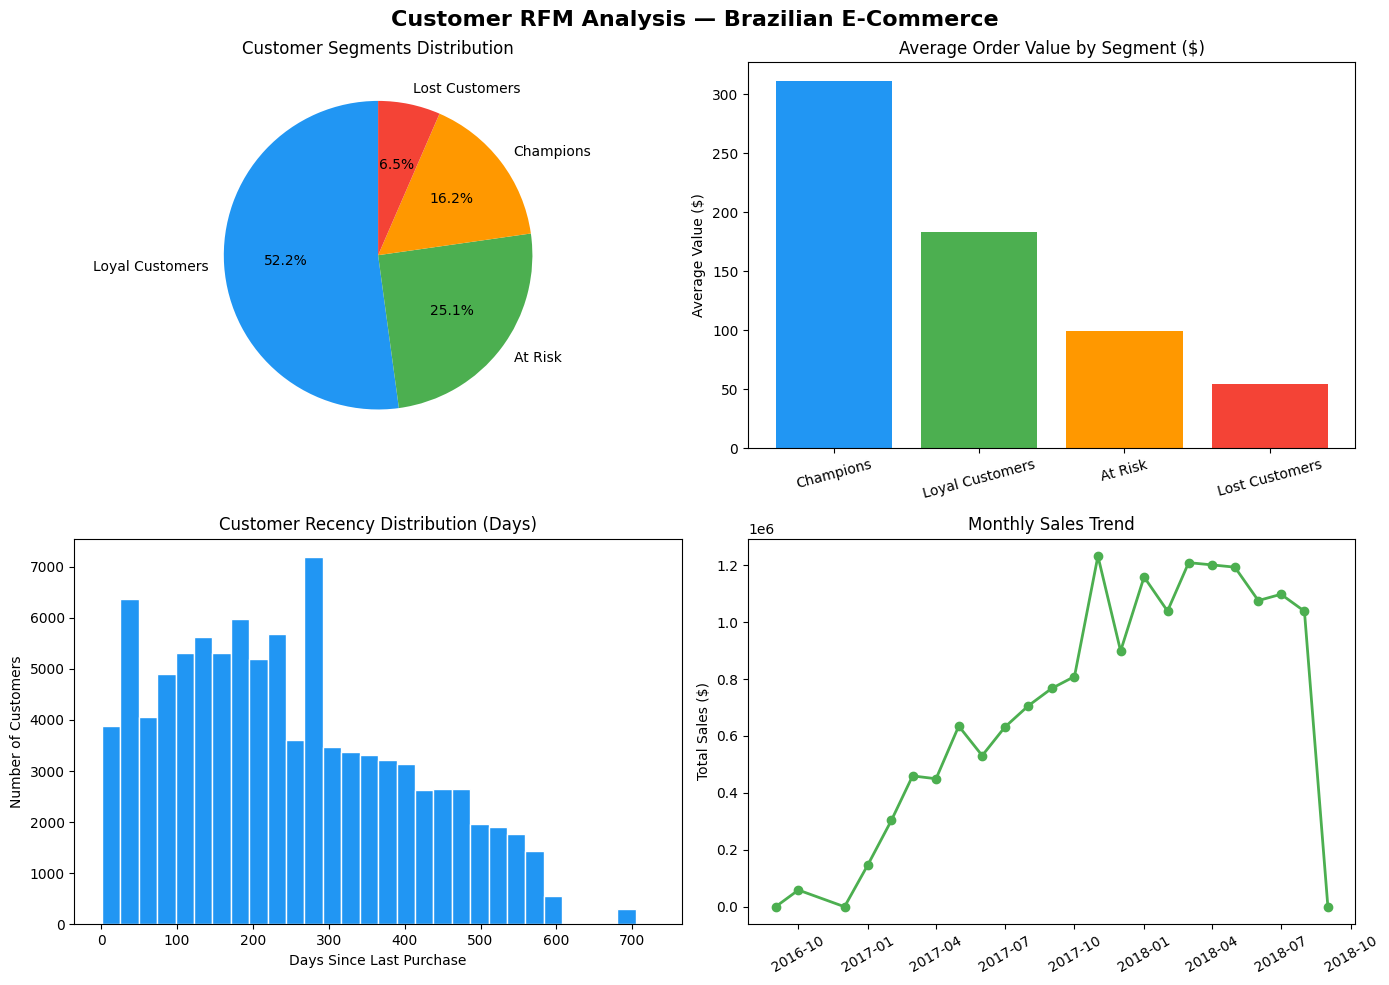

RFM Dashboard saved!


In [ ]:


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Customer RFM Analysis — Brazilian E-Commerce', 
             fontsize=16, fontweight='bold')


colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']
segment_counts = rfm['Segment'].value_counts()
axes[0, 0].pie(segment_counts.values, labels=segment_counts.index,
               colors=colors, autopct='%1.1f%%', startangle=90)
axes[0, 0].set_title('Customer Segments Distribution')


avg_monetary = rfm.groupby('Segment')['Monetary'].mean().sort_values(ascending=False)
axes[0, 1].bar(avg_monetary.index, avg_monetary.values, color=colors)
axes[0, 1].set_title('Average Order Value by Segment ($)')
axes[0, 1].set_ylabel('Average Value ($)')
axes[0, 1].tick_params(axis='x', rotation=15)


axes[1, 0].hist(rfm['Recency'], bins=30, color='#2196F3', edgecolor='white')
axes[1, 0].set_title('Customer Recency Distribution (Days)')
axes[1, 0].set_xlabel('Days Since Last Purchase')
axes[1, 0].set_ylabel('Number of Customers')


monthly_sales = df_clean.groupby(['year', 'month'])['total_order_value'].sum().reset_index()
monthly_sales['date'] = pd.to_datetime(monthly_sales[['year', 'month']].assign(day=1))
axes[1, 1].plot(monthly_sales['date'], monthly_sales['total_order_value'],
                marker='o', color='#4CAF50', linewidth=2)
axes[1, 1].set_title('Monthly Sales Trend')
axes[1, 1].set_ylabel('Total Sales ($)')
axes[1, 1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('rfm_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("RFM Dashboard saved!")

Churn added!
Churn
1    57987
0    37432
Name: count, dtype: int64
Model Accuracy: 69.2%

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.59      0.60      7394
           1       0.75      0.75      0.75     11690

    accuracy                           0.69     19084
   macro avg       0.68      0.67      0.67     19084
weighted avg       0.69      0.69      0.69     19084


Feature Importance:
     Feature  Importance
1   Monetary    0.995385
2    F_Score    0.003147
0  Frequency    0.000968
3    M_Score    0.000500


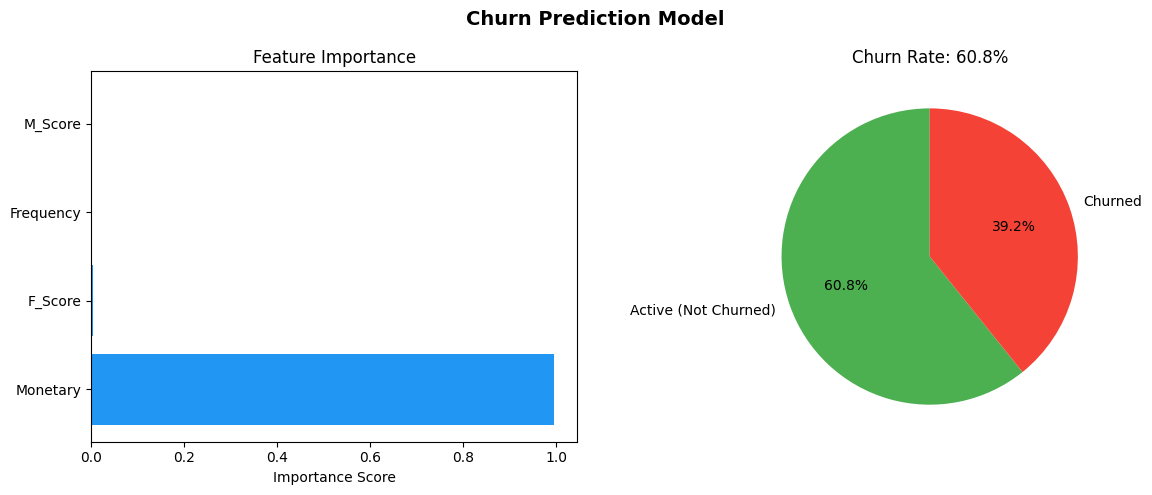

In [ ]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report


rfm['Churn'] = (rfm['Recency'] >= 180).astype(int)
print("Churn added!")
print(rfm['Churn'].value_counts())

X = rfm[['Frequency', 'Monetary', 'F_Score', 'M_Score']].astype(float)
y = rfm['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy*100:.1f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

feature_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance:")
print(feature_imp)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Churn Prediction Model', fontsize=14, fontweight='bold')


axes[0].barh(feature_imp['Feature'], feature_imp['Importance'], color='#2196F3')
axes[0].set_title('Feature Importance')
axes[0].set_xlabel('Importance Score')


churn_labels = ['Active (Not Churned)', 'Churned']
churn_values = rfm['Churn'].value_counts().values
axes[1].pie(churn_values, labels=churn_labels,
            colors=['#4CAF50', '#F44336'],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title(f'Churn Rate: {rfm["Churn"].mean()*100:.1f}%')

plt.tight_layout()
plt.savefig('churn_model.png', dpi=150, bbox_inches='tight')
plt.show()

In [2]:

summary = """
E-Commerce Customer Analysis — Brazilian Olist Dataset

Dataset: 118,307 orders | 95,000+ customers

Key Findings:
- Champions (16.2%) spend avg $315 per order
- Loyal Customers = 52% of customer base
- Churn Rate: 60.8% of customers inactive 180+ days
- Monetary value is strongest churn predictor (99.5% importance)
- Sales grew 10x from 2016 to 2018

Models Used:
- RFM Segmentation (4 segments)
- Random Forest Churn Prediction (69.2% accuracy)

Tools: Python, Pandas, Scikit-learn, Matplotlib, Seaborn
"""
print(summary)

# Save all charts
print("Files saved:")
print("- rfm_dashboard.png")
print("- churn_model.png")
print("- sales_dashboard.png")


E-Commerce Customer Analysis — Brazilian Olist Dataset

Dataset: 118,307 orders | 95,000+ customers

Key Findings:
- Champions (16.2%) spend avg $315 per order
- Loyal Customers = 52% of customer base
- Churn Rate: 60.8% of customers inactive 180+ days
- Monetary value is strongest churn predictor (99.5% importance)
- Sales grew 10x from 2016 to 2018

Models Used:
- RFM Segmentation (4 segments)
- Random Forest Churn Prediction (69.2% accuracy)

Tools: Python, Pandas, Scikit-learn, Matplotlib, Seaborn

Files saved:
- rfm_dashboard.png
- churn_model.png
- sales_dashboard.png
